### References

https://github.com/gabrielziegler3/xgboost-multiclass-multilabel/blob/master/xgboost-multiclass/multiclass-frog-classification.ipynb


In [1]:
import os

import mlflow
import mlflow.xgboost
import mlflow.sklearn

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.feature_selection import mutual_info_regression
import plotly

from sklearn.model_selection import train_test_split
from xgboost.sklearn import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt
from matplotlib import pyplot

In [2]:
not_use_cols = ['date']
#
pred_cols= [ 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow',  'f5s_25c_arrow' ]
X_cols  = ['high', 'volume', 'average', 'barCount',
           'h1s_high',  'h1s_low', 	'h1s_barCount', 'h1s_volume', 'h1s_average',
           'h2s_high', 	'h2s_low', 	'h2s_barCount', 'h2s_volume', 'h2s_average',
           'h3s_high', 	'h3s_low', 	'h3s_barCount', 'h3s_volume', 'h3s_average',
           'h4s_high', 	'h4s_low', 	'h4s_barCount', 'h4s_volume', 'h4s_average',
           'bid_avg', 	'ask_max', 	'bid_min', 	'ask_avg',
           'h1s_ask_max', 	'h1s_bid_min', 	'h1s_bid_avg', 	'h1s_ask_avg', 	'h2s_ask_max', 	'h2s_bid_min', 	'h2s_bid_avg', 	'h2s_ask_avg', 	'h3s_ask_max', 	'h3s_bid_min', 	'h3s_bid_avg', 	'h3s_ask_avg', 	'h4s_ask_max', 	'h4s_bid_min', 	'h4s_bid_avg', 	'h4s_ask_avg',
           'vix'
           ]
y_cols = pred_cols
bin_counts = 3


## mlflow logging

### [reference page](https://learn.microsoft.com/en-us/azure/machine-learning/how-to-log-view-metrics?tabs=interactive)

In [3]:
mlflow.set_experiment("vol-xgboost")
mlflow.xgboost.autolog()

In [4]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

# Code

## load data / split data

In [6]:
%%time
def load_data():
    _data1 = pd.read_csv("./contract-TSLA/TSLA-BID_ASK.csv", low_memory=False)
    _data1.set_index('date')
    _data1 = _data1.sort_index()

    _data2 = pd.read_csv("./contract-TSLA/TSLA-TRADES.csv", low_memory=False)
    _data2.set_index('date')
    _data2 = _data2.sort_index()

    _data3 = pd.merge(left=_data2, right=_data1, how="outer", on="date", validate="one_to_one")
    print ("size", _data3.shape)
    mlflow.log_param("Size", _data3.shape)
    mlflow.log_param("X cols", X_cols)
    mlflow.log_param("y col",  y_cols[1:])
    _data4 = _data3.copy(deep=True)
    _data4 = _data4.head(1000000)

    return _data4

data = load_data()

size (3679206, 56)
CPU times: user 34.5 s, sys: 7.16 s, total: 41.6 s
Wall time: 41.7 s


In [7]:
data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'average', 'barCount',
       'date2_str_x', 'h1s_high', 'h1s_low', 'h1s_barCount', 'h1s_volume',
       'h1s_average', 'h2s_high', 'h2s_low', 'h2s_barCount', 'h2s_volume',
       'h2s_average', 'h3s_high', 'h3s_low', 'h3s_barCount', 'h3s_volume',
       'h3s_average', 'h4s_high', 'h4s_low', 'h4s_barCount', 'h4s_volume',
       'h4s_average', 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow',
       'f5s_20c_arrow', 'f5s_25c_arrow', 'bid_avg', 'ask_max', 'bid_min',
       'ask_avg', 'date2_str_y', 'h1s_ask_max', 'h1s_bid_min', 'h1s_bid_avg',
       'h1s_ask_avg', 'h2s_ask_max', 'h2s_bid_min', 'h2s_bid_avg',
       'h2s_ask_avg', 'h3s_ask_max', 'h3s_bid_min', 'h3s_bid_avg',
       'h3s_ask_avg', 'h4s_ask_max', 'h4s_bid_min', 'h4s_bid_avg',
       'h4s_ask_avg', 'vix'],
      dtype='object')

In [8]:
data.shape

(1000000, 56)

In [9]:
def rebase(low,
           c1, c2, c3, c4, c5, c6, c7, c8, c9, c10,
           c11, c12, c13, c14, c15, c16, c17, c18, c19, c20,
           c21, c22, c23, c24, c25, c26, c27, c28, c29, c30,
           c31, c32, c33, c34, c35, c36, c37):
   return pd.Series([
       c1 - low, c2 - low, c3 - low, c4 - low, c5 - low,
       c6 - low, c7 - low, c8 - low, c9 - low, c10 - low,
       c11 - low, c12 - low, c13 - low, c14 - low, c15 - low,
       c16 - low, c17 - low, c18 - low, c19 - low, c20 - low,
       c21 - low, c22 - low, c23 - low, c24 - low, c25 - low,
       c26 - low, c27 - low, c28 - low, c29 - low, c30 - low,
       c31 - low, c32 - low, c33 - low, c34 - low, c35 - low,
       c36 - low, c37 - low ])

In [10]:
data.head(100)

,date,open,high,low,close,volume,average,barCount,date2_str_x,h1s_high,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,2022-06-24 12:29:54,243.5433,243.5433,243.5433,243.5433,0.00,243.543,0.0,2022-06-24,NaN,...,243.5867,243.6000,243.5000,243.5003,243.5933,243.5967,243.4933,243.5130,243.5967,27.40
1,2022-06-24 12:29:55,243.5833,243.5833,243.5833,243.5833,3.27,243.583,1.0,2022-06-24,243.5433,...,243.5867,243.5933,243.5000,243.5000,243.5867,243.6000,243.5000,243.5003,243.5933,27.40
2,2022-06-24 12:29:56,243.5433,243.5433,243.5433,243.5433,15.00,243.543,1.0,2022-06-24,243.5833,...,243.5833,243.5867,243.5000,243.5000,243.5867,243.5933,243.5000,243.5000,243.5867,27.40
3,2022-06-24 12:29:57,243.5433,243.5433,243.5433,243.5433,3.00,243.543,1.0,2022-06-24,243.5433,...,243.5833,243.5867,243.5000,243.5000,243.5833,243.5867,243.5000,243.5000,243.5867,27.40
4,2022-06-24 12:29:58,243.5500,243.5500,243.5500,243.5500,6.00,243.550,1.0,2022-06-24,243.5433,...,243.5867,243.5833,243.5000,243.5033,243.5833,243.5867,243.5000,243.5000,243.5833,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-06-24 12:31:29,243.4600,243.4633,243.4600,243.4600,3.00,243.461,1.0,2022-06-24,243.4200,...,243.4200,243.4200,243.3067,243.3433,243.4200,243.4200,243.3067,243.3070,243.3800,27.39
96,2022-06-24 12:31:30,243.4600,243.4633,243.4600,243.4600,0.00,243.460,0.0,2022-06-24,243.4633,...,243.4760,243.4200,243.3067,243.3067,243.4200,243.4200,243.3067,243.3433,243.4200,27.39
97,2022-06-24 12:31:31,243.4200,243.4233,243.4200,243.4200,10.50,243.420,1.0,2022-06-24,243.4633,...,243.4767,243.5033,243.3067,243.3857,243.4760,243.4200,243.3067,243.3067,243.4200,27.36
98,2022-06-24 12:31:32,243.4200,243.4233,243.4200,243.4200,0.00,243.420,0.0,2022-06-24,243.4233,...,243.4237,243.4833,243.3867,243.3867,243.4767,243.5033,243.3067,243.3857,243.4760,27.36


In [11]:
%%time
data[['open', 'high', 'close', 'average',
	'h1s_high', 'h1s_low', 'h1s_average',
	'h2s_high', 'h2s_low', 'h2s_average',
	'h3s_high', 'h3s_low', 'h3s_average',
	'h4s_high', 'h4s_low', 'h4s_average',
	'f5s_average',
	'bid_avg', 'ask_max', 'bid_min', 'ask_avg',
	'h1s_ask_max', 'h1s_bid_min', 'h1s_bid_avg', 'h1s_ask_avg',
	'h2s_ask_max', 'h2s_bid_min', 'h2s_bid_avg', 'h2s_ask_avg',
	'h3s_ask_max', 'h3s_bid_min', 'h3s_bid_avg', 'h3s_ask_avg',
	'h4s_ask_max', 'h4s_bid_min', 'h4s_bid_avg', 'h4s_ask_avg']] = data.apply(lambda x:
		rebase(x['low'], x['open'], x['high'], x['close'], x['average'],
		x['h1s_high'], x['h1s_low'], x['h1s_average'],
		x['h2s_high'], x['h2s_low'], x['h2s_average'],
		x['h3s_high'], x['h3s_low'], x['h3s_average'],
		x['h4s_high'], x['h4s_low'], x['h4s_average'],
	x['f5s_average'],
	x['bid_avg'], x['ask_max'], x['bid_min'], x['ask_avg'],
	x['h1s_ask_max'], x['h1s_bid_min'], x['h1s_bid_avg'], x['h1s_ask_avg'],
	x['h2s_ask_max'], x['h2s_bid_min'], x['h2s_bid_avg'], x['h2s_ask_avg'],
	x['h3s_ask_max'], x['h3s_bid_min'], x['h3s_bid_avg'], x['h3s_ask_avg'],
	x['h4s_ask_max'], x['h4s_bid_min'], x['h4s_bid_avg'], x['h4s_ask_avg']), axis=1)

CPU times: user 2min 11s, sys: 2.94 s, total: 2min 14s
Wall time: 2min 14s


In [39]:
data.head(100)

,date,open,high,low,close,volume,average,barCount,date2_str_x,h1s_high,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,2022-06-24 12:29:54,0.0,0.0000,243.5433,0.0,0.00,-0.0003,0.0,2022-06-24,NaN,...,0.0434,0.0567,-0.0433,-0.0430,0.0500,0.0534,-0.0500,-0.0303,0.0534,27.40
1,2022-06-24 12:29:55,0.0,0.0000,243.5833,0.0,3.27,-0.0003,1.0,2022-06-24,-0.0400,...,0.0034,0.0100,-0.0833,-0.0833,0.0034,0.0167,-0.0833,-0.0830,0.0100,27.40
2,2022-06-24 12:29:56,0.0,0.0000,243.5433,0.0,15.00,-0.0003,1.0,2022-06-24,0.0400,...,0.0400,0.0434,-0.0433,-0.0433,0.0434,0.0500,-0.0433,-0.0433,0.0434,27.40
3,2022-06-24 12:29:57,0.0,0.0000,243.5433,0.0,3.00,-0.0003,1.0,2022-06-24,0.0000,...,0.0400,0.0434,-0.0433,-0.0433,0.0400,0.0434,-0.0433,-0.0433,0.0434,27.40
4,2022-06-24 12:29:58,0.0,0.0000,243.5500,0.0,6.00,0.0000,1.0,2022-06-24,-0.0067,...,0.0367,0.0333,-0.0500,-0.0467,0.0333,0.0367,-0.0500,-0.0500,0.0333,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-06-24 12:31:29,0.0,0.0033,243.4600,0.0,3.00,0.0010,1.0,2022-06-24,-0.0400,...,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,-0.0400,-0.1533,-0.1530,-0.0800,27.39
96,2022-06-24 12:31:30,0.0,0.0033,243.4600,0.0,0.00,0.0000,0.0,2022-06-24,0.0033,...,0.0160,-0.0400,-0.1533,-0.1533,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,27.39
97,2022-06-24 12:31:31,0.0,0.0033,243.4200,0.0,10.50,0.0000,1.0,2022-06-24,0.0433,...,0.0567,0.0833,-0.1133,-0.0343,0.0560,0.0000,-0.1133,-0.1133,0.0000,27.36
98,2022-06-24 12:31:32,0.0,0.0033,243.4200,0.0,0.00,0.0000,0.0,2022-06-24,0.0033,...,0.0037,0.0633,-0.0333,-0.0333,0.0567,0.0833,-0.1133,-0.0343,0.0560,27.36


In [44]:
X = data[X_cols]
y = data [y_cols [1:]]

In [45]:
X.head(100)

,high,volume,average,barCount,h1s_high,h1s_low,h1s_barCount,h1s_volume,h1s_average,h2s_high,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,0.0000,0.00,-0.0003,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0434,0.0567,-0.0433,-0.0430,0.0500,0.0534,-0.0500,-0.0303,0.0534,27.40
1,0.0000,3.27,-0.0003,1.0,-0.0400,-0.0400,0.0,0.00,-0.0403,NaN,...,0.0034,0.0100,-0.0833,-0.0833,0.0034,0.0167,-0.0833,-0.0830,0.0100,27.40
2,0.0000,15.00,-0.0003,1.0,0.0400,0.0400,1.0,3.27,0.0397,0.0000,...,0.0400,0.0434,-0.0433,-0.0433,0.0434,0.0500,-0.0433,-0.0433,0.0434,27.40
3,0.0000,3.00,-0.0003,1.0,0.0000,0.0000,1.0,15.00,-0.0003,0.0400,...,0.0400,0.0434,-0.0433,-0.0433,0.0400,0.0434,-0.0433,-0.0433,0.0434,27.40
4,0.0000,6.00,0.0000,1.0,-0.0067,-0.0067,1.0,3.00,-0.0070,-0.0067,...,0.0367,0.0333,-0.0500,-0.0467,0.0333,0.0367,-0.0500,-0.0500,0.0333,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0033,3.00,0.0010,1.0,-0.0400,-0.0933,2.0,6.00,-0.0670,-0.0800,...,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,-0.0400,-0.1533,-0.1530,-0.0800,27.39
96,0.0033,0.00,0.0000,0.0,0.0033,0.0000,1.0,3.00,0.0010,-0.0400,...,0.0160,-0.0400,-0.1533,-0.1533,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,27.39
97,0.0033,10.50,0.0000,1.0,0.0433,0.0400,0.0,0.00,0.0400,0.0433,...,0.0567,0.0833,-0.1133,-0.0343,0.0560,0.0000,-0.1133,-0.1133,0.0000,27.36
98,0.0033,0.00,0.0000,0.0,0.0033,0.0000,1.0,10.50,0.0000,0.0433,...,0.0037,0.0633,-0.0333,-0.0333,0.0567,0.0833,-0.1133,-0.0343,0.0560,27.36


In [46]:
y.head(100)

,f5s_10c_arrow,f5s_15c_arrow,f5s_20c_arrow,f5s_25c_arrow
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
...,...,...,...,...
95,0.0,0.0,0.0,0.0
96,-1.0,-1.0,0.0,0.0
97,-1.0,0.0,0.0,0.0
98,-1.0,-1.0,0.0,0.0


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
msg = f"Train {X_train.shape},{y_train.shape}, Test {X_test.shape}, {y_test.shape}"
print (msg)

Train (700000, 45),(700000, 4), Test (300000, 45), (300000, 4)


## Scale Data

In [ ]:
# Standard Scaled X Prediction
scalar = StandardScaler()
scalar.fit(X_train)
X_train = pd.DataFrame(scalar.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scalar.transform(X_test), columns=X_test.columns)
#x_train = scalar.transform(x_train)
#x_test = scalar.transform(x_test)


In [48]:
# XGB Parameters

#  https://xgboost.readthedocs.io/en/stable/parameter.html
params2 = {
        'objective': 'multi:softprob',
        'enable_categorical': False,
        'eval_metric': 'merror',  # mlogloss or merror,
        # 'eval_metric': 'multi:softprob'
}
params = {
        'copy_X': True,
        'fit_intercept': False,
        'normalize': True,
        '_kfold': 2,
        # 'objective': 'validation:accuracy',
        'objective': 'multi:softprob',
        'num_class': bin_counts,
        # 'objective': 'binary:logistic',
        'enable_categorical': False,
        '_tuning_objective_metric': 'validation:f1',
        'eval_metric': 'auc',
        # 'tree_method': 'gpu_hist',
        # 'eval_metric': 'accuracy,f1',
        # 'eval_metric':'merror',
        # 'eval_metric': 'accuracy,f1X',
        # Muthu params
        #'subsample': 0.75,  # Setting it to 0.5 means that XGBoost would randomly sample half of the training data prior to growing trees. and this will prevent overfitting.
        'gamma': 0.001,  # Minimum loss reduction required to make a further partition on a leaf node of the tree. The larger gamma is, the more conservative the algorithm will be
        'alpha': 0.0,  # L1 regularization is Lasso Regression wich adds “squared magnitude” of coefficient as penalty term to the loss functi
        'lambda': 1.0,  # L2 regularization is Ridge Regression which adds “absolute value of magnitude” of coefficient as penalty term to the loss function.
        'eta': 0.03,  # Step size shrinkage used in update to prevents overfitting
        'min_child_weight': 0.05,  # Minimum sum of instance weight (hessian) needed in a child the building process will give up further partitioning.
        # not too sure.
        'max_depth': 10,  # Maximum tree depth for base learners.
        # 'early_stopping_rounds': 50,  # don't over fit
        'num_round': 100,  # num_boost_round == num_boost_round
        'use_label_encoder': False # UserWarning: The use of label encoder in XGBClassifier is deprecated...
    }

In [49]:
# fig, ax = plt.subplots()
#sns.set(rc={'figure.figsize': (12, 9)})
# x_train.plot.hist(alpha=0.5)
#ax = x_train.hist()
# x_train.hist()
# fig = ax.get_figure()
#ax.figure.savefig('TrainingHistogram.png')
#mlflow.log_figure(fig, "TrainingHistogram.png")
# plt.show()
#data2 = data [x_cols + y_cols ]
#data2.plot.hist();
#corr = data2.corr()
#corr.style.background_gradient(cmap='coolwarm').set_precision(2)
#plt.show()
#print(corr)
#sns.set(rc={'figure.figsize':(66,48)})
#sns.heatmap(corr, annot=True)


In [50]:
#df = data.head(1000)
#plt.matshow(df.corr())
#corr = df.corr()
#corr.style.background_gradient(cmap='coolwarm').set_precision(2)
#plt.show()
#print(corr)
#sns.heatmap(corr, annot=True)


## Create XGB Model

In [51]:
#Y_cols = [ 'f5s_average', 'f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow',  'f5s_25c_arrow']

xgb_f10 = XGBClassifier(**params2)
xgb_f15 = XGBClassifier(**params2)
xgb_f20 = XGBClassifier(**params2)
xgb_f25 = XGBClassifier(**params2)

#print(xgb.get_xgb_params())
#mlflow.log_param('xgb_params', xgb.get_xgb_params())
#mlflow.xgboost.autolog()


In [52]:
y_train.columns

Index(['f5s_10c_arrow', 'f5s_15c_arrow', 'f5s_20c_arrow', 'f5s_25c_arrow'], dtype='object')

In [53]:
%%time
# Train model & predict
xgb_f10.fit(X_train, y_train['f5s_10c_arrow'])
xgb_f15.fit(X_train, y_train['f5s_15c_arrow'])
xgb_f20.fit(X_train, y_train['f5s_20c_arrow'])
xgb_f25.fit(X_train, y_train['f5s_25c_arrow'])

2022/10/23 04:47:40 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '7824a1ce06ff4da3acadb66895475a17', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
/Users/Muthu/Development/OptionList4/lib/python3.9/site-packages/xgboost/sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
2022/10/23 04:50:14 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '00d1af0fd020474eb57c25ae8de9f22d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
20

CPU times: user 1h 26min 19s, sys: 3min 22s, total: 1h 29min 41s
Wall time: 10min 25s


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              eval_metric='merror', gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=10,
              num_parallel_tree=1, objective='multi:softprob', predictor='auto',
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=None,
              subsample=1, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [54]:
%%time
y_f10_pred = xgb_f10.predict(X_test)
y_f15_pred = xgb_f15.predict(X_test)
y_f20_pred = xgb_f20.predict(X_test)
y_f25_pred = xgb_f25.predict(X_test)

CPU times: user 9.26 s, sys: 228 ms, total: 9.49 s
Wall time: 1.04 s


In [55]:
#average setting, one of [None, 'micro', 'macro', 'weighted']
# precision, recall, f1, y_true = precision_recall_fscore_support(y_test, y_pred, average='weighted')

ps = precision_score(y_test['f5s_10c_arrow'], y_f10_pred, average='weighted')
rs = recall_score(y_test['f5s_10c_arrow'], y_f10_pred, average='weighted')
ac = accuracy_score(y_test['f5s_10c_arrow'], y_f10_pred)
print(f"f10_accuracy: {round(ac, 3)} f10_precision {round(ps, 3)} f10_recall {round(rs, 3)}")
mlflow.log_metrics({'f10_accuracy': round(ac, 3), 'f10_precision': round(ps, 3), 'f10_recall': round(rs, 3)})


ps = precision_score(y_test['f5s_15c_arrow'], y_f15_pred, average='weighted')
rs = recall_score(y_test['f5s_15c_arrow'], y_f15_pred, average='weighted')
ac = accuracy_score(y_test['f5s_15c_arrow'], y_f15_pred)
print(f"f15_accuracy: {round(ac, 3)} f15_precision {round(ps, 3)} f15_recall {round(rs, 3)}")
mlflow.log_metrics({'f15_accuracy': round(ac, 3), 'f15_precision': round(ps, 3), 'f15_recall': round(rs, 3)})

ps = precision_score(y_test['f5s_20c_arrow'], y_f20_pred, average='weighted')
rs = recall_score(y_test['f5s_20c_arrow'], y_f20_pred, average='weighted')
ac = accuracy_score(y_test['f5s_20c_arrow'], y_f20_pred)
print(f"f20_accuracy: {round(ac, 3)} f20_precision {round(ps, 3)} f20_recall {round(rs, 3)}")
mlflow.log_metrics({'f20_accuracy': round(ac, 3), 'f20_precision': round(ps, 3), 'f20_recall': round(rs, 3)})

ps = precision_score(y_test['f5s_25c_arrow'], y_f25_pred, average='weighted')
rs = recall_score(y_test['f5s_25c_arrow'], y_f25_pred, average='weighted')
ac = accuracy_score(y_test['f5s_25c_arrow'], y_f25_pred)
print(f"f25_accuracy: {round(ac, 3)} f25_precision {round(ps, 3)} f25_recall {round(rs, 3)}")
mlflow.log_metrics({'f25_accuracy': round(ac, 3), 'f25_precision': round(ps, 3), 'f25_recall': round(rs, 3)})


f10_accuracy: 0.69 f10_precision 0.632 f10_recall 0.69
f15_accuracy: 0.823 f15_precision 0.763 f15_recall 0.823
f20_accuracy: 0.897 f20_precision 0.852 f20_recall 0.897
f25_accuracy: 0.937 f25_precision 0.905 f25_recall 0.937


In [56]:
def plot_confusion_matrix(cm, classes, normalized=True, cmap='bone', fmt='.3g'):
    #plt.figure(figsize=[7, 6])
    plt.figure(figsize=[14, 12])
    norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print(cm)
    print(norm_cm)

    arr = [["-"]*len(cm)]*len(cm)
    for j in range(len(cm)):
        for i in range(len(cm[j])):
            arr[j][i] =  f"{cm[j][i]:,d}\n{norm_cm[j][i]:.3f}%"
            print(cm[j][i], arr[j][i])
    print(arr)
    sns.heatmap(norm_cm, annot=arr, annot_kws={'size': 15}, fmt='s', normalize=True)

In [57]:
def plot_confusion_matrix2(_cm, _title):
    plt.figure(figsize=[14, 12])
    disp = ConfusionMatrixDisplay(confusion_matrix=_cm, display_labels=[-1, 0, 1])
    disp.plot(cmap=plt.cm.Paired,  values_format=',')
    fig = disp.ax_.get_figure()
    fig.set_figwidth(12)
    fig.set_figheight(12)
    # print (plt.rcParams.keys())
    plt.rcParams.update({'font.size': 22})
    plt.show()
    mlflow.log_figure(fig, _title)


<Figure size 1008x864 with 0 Axes>

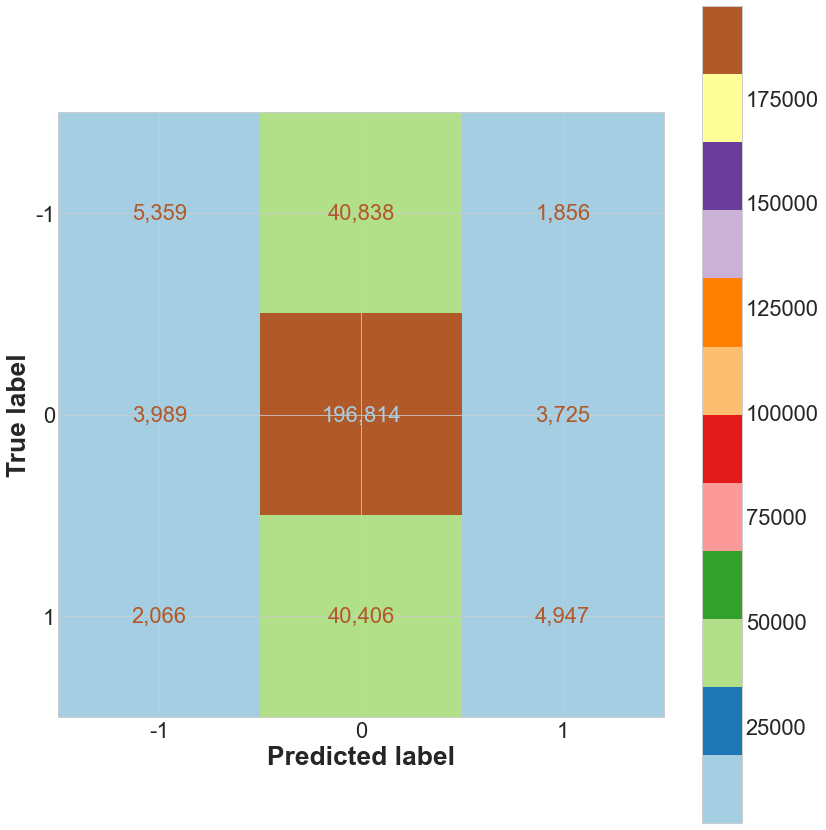

<Figure size 1008x864 with 0 Axes>

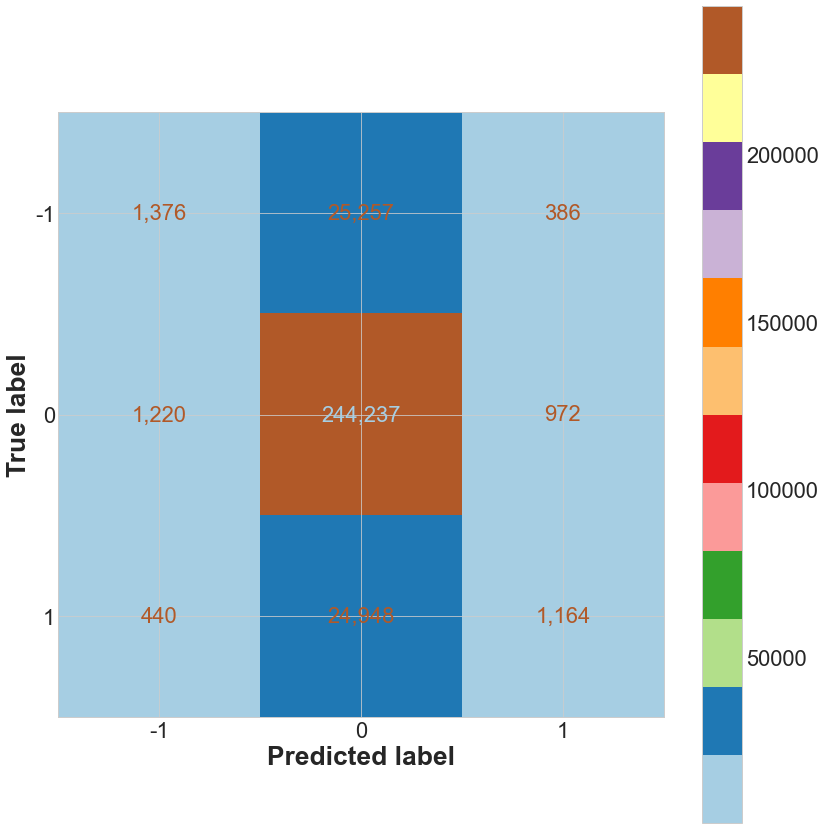

<Figure size 1008x864 with 0 Axes>

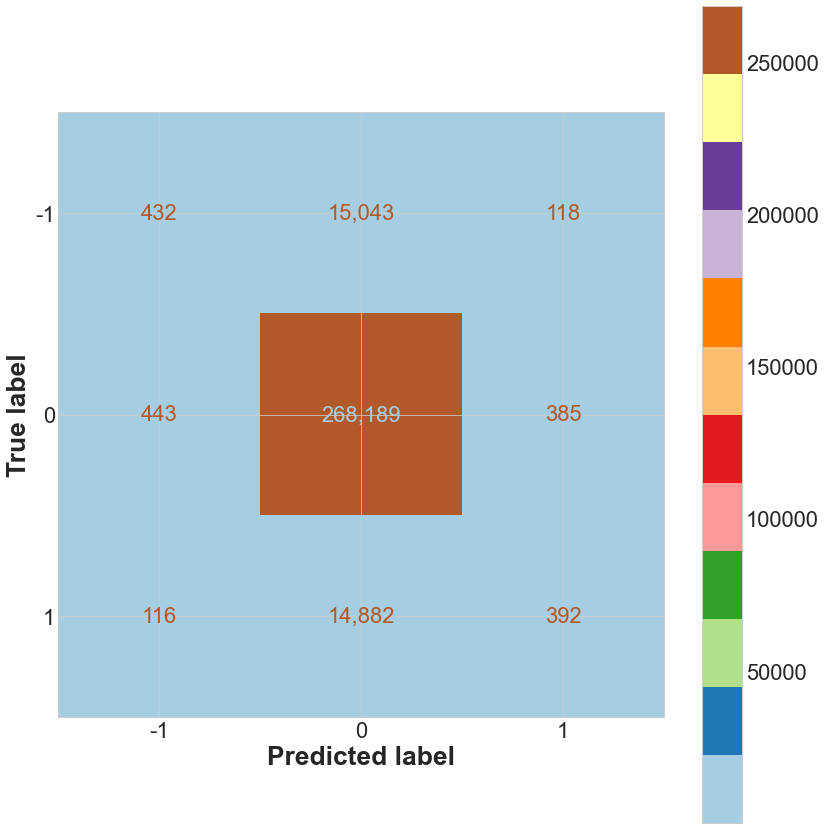

<Figure size 1008x864 with 0 Axes>

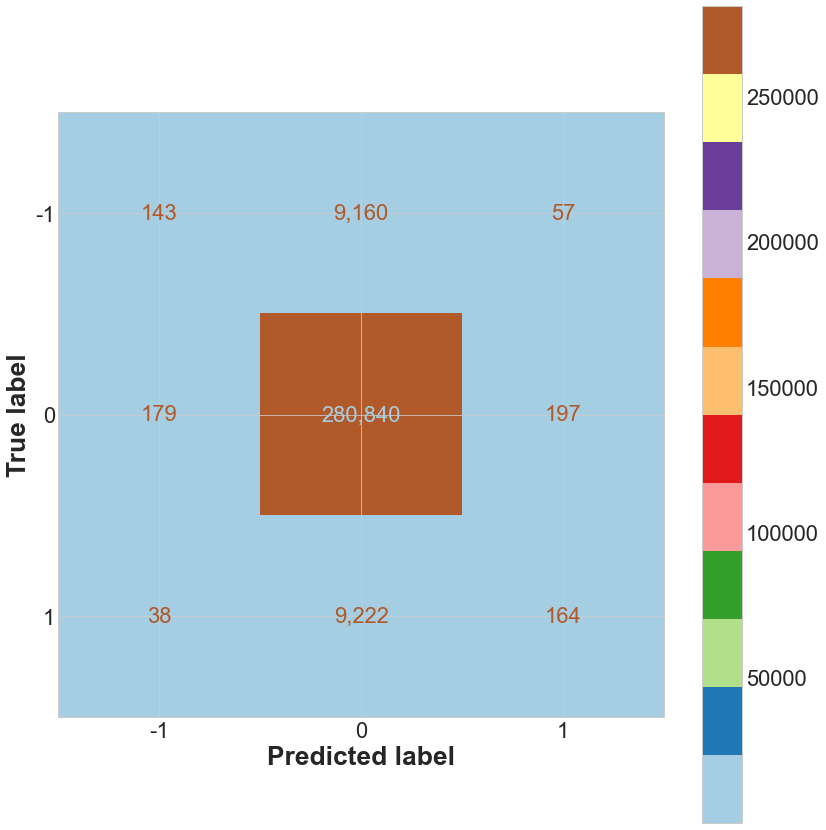

[[  5359  40838   1856]
 [  3989 196814   3725]
 [  2066  40406   4947]]
[[  1376  25257    386]
 [  1220 244237    972]
 [   440  24948   1164]]
[[   432  15043    118]
 [   443 268189    385]
 [   116  14882    392]]
[[   143   9160     57]
 [   179 280840    197]
 [    38   9222    164]]


In [58]:
cm_f10 = confusion_matrix(y_test['f5s_10c_arrow'], y_f10_pred, labels=[-1,0,1])
cm_f15 = confusion_matrix(y_test['f5s_15c_arrow'], y_f15_pred, labels=[-1,0,1])
cm_f20 = confusion_matrix(y_test['f5s_20c_arrow'], y_f20_pred, labels=[-1,0,1])
cm_f25 = confusion_matrix(y_test['f5s_25c_arrow'], y_f25_pred, labels=[-1,0,1])
# norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plot_confusion_matrix2(cm_f10, 'f10_confusion_matrix.png')
plot_confusion_matrix2(cm_f15, 'f15_confusion_matrix.png')
plot_confusion_matrix2(cm_f20, 'f20_confusion_matrix.png')
plot_confusion_matrix2(cm_f25, 'f25_confusion_matrix.png')

print(cm_f10)
print(cm_f15)
print(cm_f20)
print(cm_f25)


In [59]:
print(cm_f10)
print(cm_f15)
print(cm_f20)
print(cm_f25)

[[  5359  40838   1856]
 [  3989 196814   3725]
 [  2066  40406   4947]]
[[  1376  25257    386]
 [  1220 244237    972]
 [   440  24948   1164]]
[[   432  15043    118]
 [   443 268189    385]
 [   116  14882    392]]
[[   143   9160     57]
 [   179 280840    197]
 [    38   9222    164]]


In [60]:
cm_f10_json = {}
cm_f10_json.update({"f10_Confusion_Matrix": cm_f10})
mlflow.log_param("f10_confusion_matrix.json", cm_f10_json)
print(cm_f10_json)

cm_f15_json = {}
cm_f15_json.update({"f15_Confusion_Matrix": cm_f15})
mlflow.log_param("f15_confusion_matrix.json", cm_f15_json)
print(cm_f15_json)

cm_f20_json = {}
cm_f20_json.update({"f20_Confusion_Matrix": cm_f20})
mlflow.log_param("f20_confusion_matrix.json", cm_f20_json)
print(cm_f20_json)

cm_f25_json = {}
cm_f25_json.update({"f25_Confusion_Matrix": cm_f25})
mlflow.log_param("f25_confusion_matrix.json", cm_f25_json)
print(cm_f25_json)

{'f10_Confusion_Matrix': array([[  5359,  40838,   1856],
       [  3989, 196814,   3725],
       [  2066,  40406,   4947]])}
{'f15_Confusion_Matrix': array([[  1376,  25257,    386],
       [  1220, 244237,    972],
       [   440,  24948,   1164]])}
{'f20_Confusion_Matrix': array([[   432,  15043,    118],
       [   443, 268189,    385],
       [   116,  14882,    392]])}
{'f25_Confusion_Matrix': array([[   143,   9160,     57],
       [   179, 280840,    197],
       [    38,   9222,    164]])}


In [61]:
# from mlflow.models.signature import infer_signature
# signature = infer_signature(x_train, xgb.predict(xgb.DMatrix(data=x_train, label=y_train)))
# mlflow.xgboost.log_model(xgb, "model") #, signature=signature)""
#fig, ax = plt.subplots()
#sns.set(rc = {'figure.figsize':(12,9)})
#ns.heatmap(cm, annot=True, cmap="YlGnBu",fmt='d')
#fig.savefig("ConfusionMatrix.png")
#mlflow.log_figure(fig, "ConfusionMatrix.png")
#plt.show()

#sns.heatmap(cm_pct, annot=True, cmap="YlGnBu", fmt=".3f")
#fig.savefig("ConfusionMatrixPct.png")
#mlflow.log_figure(fig, "ConfusionMatrixPct.png")
#plt.show()


# feature_importances = pd.DataFrame(xgb.feature_importances_,index=x_train.columns.tolist(),columns=['importance'])
# feature_importances.sort_values('importance', ascending=False)


In [62]:
def print_fi(xgb, name):
    feature_importance = pd.DataFrame(xgb.feature_importances_,index=X_train.columns.tolist(),columns=['importance'])
    vals = feature_importance.sort_values('importance', ascending=False)
    mlflow.log_param(name, vals.to_string)
    print (name)
    print(vals)


    #_x = pd.Series(xgb.feature_importances_, index=X_train.columns).nlargest(12).plot(kind='barh')
    _x = pyplot.barh(range(len(xgb.feature_importances_)), xgb.feature_importances_, )
    plt.show()
    #mlflow.log_image(image, name)
    return

f10_feature_importance
              importance
ask_max         0.159185
ask_avg         0.114134
bid_avg         0.079965
average         0.057036
vix             0.033087
h1s_bid_min     0.030193
h4s_bid_min     0.029921
h4s_ask_max     0.024881
h1s_ask_max     0.023653
h3s_barCount    0.020981
bid_min         0.019412
high            0.018747
h3s_bid_min     0.018487
h1s_high        0.017600
h3s_ask_max     0.015913
h1s_barCount    0.015688
h4s_volume      0.015618
h2s_barCount    0.015460
h2s_ask_max     0.015453
h4s_barCount    0.015429
h4s_low         0.014795
barCount        0.014116
h4s_high        0.013088
h2s_bid_min     0.012251
h2s_volume      0.012224
h2s_low         0.012115
h1s_low         0.011885
h1s_bid_avg     0.011547
h1s_ask_avg     0.011179
h4s_ask_avg     0.010736
h1s_volume      0.010522
h3s_volume      0.010436
h2s_high        0.010231
h4s_bid_avg     0.009911
h3s_ask_avg     0.009835
h2s_bid_avg     0.009590
h3s_low         0.009194
volume          0.008636
h3

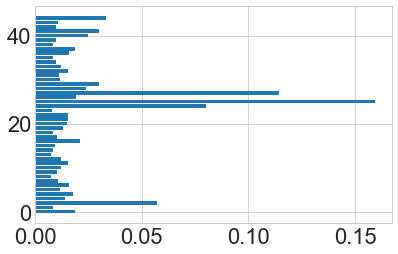

f15_feature_importance
              importance
ask_max         0.155839
ask_avg         0.102224
bid_avg         0.066633
average         0.048051
high            0.039676
h1s_bid_min     0.037114
h1s_ask_max     0.028858
h4s_bid_min     0.027135
h4s_ask_max     0.026846
vix             0.026366
h3s_barCount    0.021268
h2s_bid_min     0.020669
h3s_bid_min     0.020413
h1s_high        0.019107
h3s_ask_max     0.018439
h4s_barCount    0.018257
h2s_barCount    0.016728
h2s_ask_max     0.014453
h2s_volume      0.014379
h4s_volume      0.014349
h1s_barCount    0.013834
bid_min         0.013519
h4s_low         0.012930
h1s_ask_avg     0.012294
h1s_volume      0.012177
h1s_low         0.012121
h3s_volume      0.012033
barCount        0.012005
h4s_high        0.011040
h4s_bid_avg     0.010961
h3s_ask_avg     0.010960
h4s_ask_avg     0.010954
h1s_bid_avg     0.010727
h2s_low         0.010580
h3s_low         0.010167
h2s_high        0.010110
h3s_high        0.009714
h2s_ask_avg     0.009182
h3

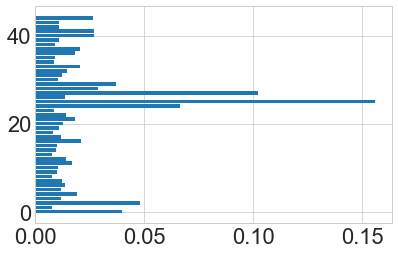

f20_feature_importance
              importance
ask_max         0.146310
ask_avg         0.090357
high            0.069668
bid_avg         0.050106
h1s_bid_min     0.031700
average         0.030980
h4s_bid_min     0.029880
h2s_bid_min     0.029094
h4s_ask_max     0.026493
h1s_ask_max     0.025240
h1s_high        0.023900
vix             0.023221
h3s_barCount    0.020783
h3s_bid_min     0.019822
h4s_barCount    0.019186
h3s_ask_max     0.019038
h2s_barCount    0.017699
h2s_ask_max     0.016928
h1s_volume      0.015183
h1s_bid_avg     0.014526
h4s_volume      0.013943
h2s_volume      0.013916
h1s_ask_avg     0.013835
h3s_volume      0.013580
h1s_barCount    0.013518
h1s_low         0.013226
h4s_low         0.012999
h4s_bid_avg     0.012504
h3s_ask_avg     0.011658
h4s_ask_avg     0.011477
h3s_low         0.011429
h4s_high        0.011377
h3s_high        0.011041
bid_min         0.010996
h2s_low         0.010806
h3s_bid_avg     0.010420
barCount        0.010313
h2s_high        0.009952
h2

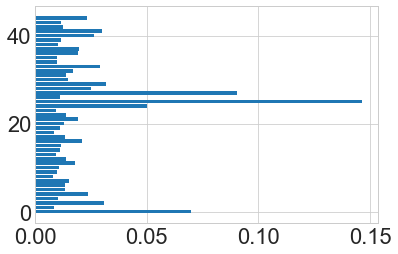

f25_feature_importance
              importance
ask_max         0.135860
ask_avg         0.083653
high            0.058411
bid_avg         0.043251
h1s_high        0.035848
h1s_ask_max     0.034533
h4s_bid_min     0.033961
h1s_bid_min     0.033516
h3s_barCount    0.025093
average         0.023112
h2s_bid_min     0.022928
h2s_barCount    0.022736
h4s_ask_max     0.022246
vix             0.021431
h4s_barCount    0.020534
h3s_ask_max     0.020101
h3s_bid_min     0.019385
h2s_ask_max     0.017264
h1s_bid_avg     0.015608
h4s_volume      0.014895
h3s_volume      0.014811
h1s_barCount    0.014219
h4s_bid_avg     0.014211
h2s_volume      0.014064
h4s_ask_avg     0.013114
h1s_volume      0.012974
h1s_low         0.012771
h3s_low         0.012347
h4s_low         0.012198
bid_min         0.012196
h3s_ask_avg     0.012125
h1s_ask_avg     0.012094
h2s_ask_avg     0.011856
h3s_high        0.011407
h3s_bid_avg     0.011270
h2s_bid_avg     0.011237
h2s_low         0.011219
h4s_high        0.010960
vo

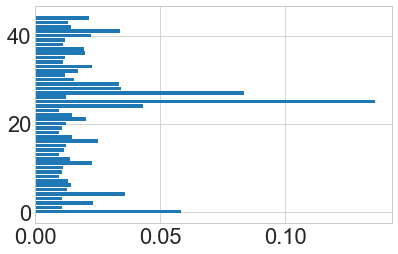

In [63]:
print_fi( xgb_f10, 'f10_feature_importance')
print_fi( xgb_f15, 'f15_feature_importance')
print_fi( xgb_f20, 'f20_feature_importance')
print_fi( xgb_f25, 'f25_feature_importance')

In [64]:
mlflow.end_run()

# ToDo

* add history: h1, h2, h3, h4, h5.  There seems to be no value for >5
* filter time to 9:45 - 15:45
* remove non-full days
* add vix index
* move data to MySQL

DONE:

* Create multiple arrow buckets ('f5s_10c_arrow', 'f5s_20c_arrow') += 'f5s_15c_arrow', 'f5s_25c_arrow', 'f5s_30c_arrow'

In [65]:
data.head(100)

,date,open,high,low,close,volume,average,barCount,date2_str_x,h1s_high,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
0,2022-06-24 12:29:54,0.0,0.0000,243.5433,0.0,0.00,-0.0003,0.0,2022-06-24,NaN,...,0.0434,0.0567,-0.0433,-0.0430,0.0500,0.0534,-0.0500,-0.0303,0.0534,27.40
1,2022-06-24 12:29:55,0.0,0.0000,243.5833,0.0,3.27,-0.0003,1.0,2022-06-24,-0.0400,...,0.0034,0.0100,-0.0833,-0.0833,0.0034,0.0167,-0.0833,-0.0830,0.0100,27.40
2,2022-06-24 12:29:56,0.0,0.0000,243.5433,0.0,15.00,-0.0003,1.0,2022-06-24,0.0400,...,0.0400,0.0434,-0.0433,-0.0433,0.0434,0.0500,-0.0433,-0.0433,0.0434,27.40
3,2022-06-24 12:29:57,0.0,0.0000,243.5433,0.0,3.00,-0.0003,1.0,2022-06-24,0.0000,...,0.0400,0.0434,-0.0433,-0.0433,0.0400,0.0434,-0.0433,-0.0433,0.0434,27.40
4,2022-06-24 12:29:58,0.0,0.0000,243.5500,0.0,6.00,0.0000,1.0,2022-06-24,-0.0067,...,0.0367,0.0333,-0.0500,-0.0467,0.0333,0.0367,-0.0500,-0.0500,0.0333,27.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-06-24 12:31:29,0.0,0.0033,243.4600,0.0,3.00,0.0010,1.0,2022-06-24,-0.0400,...,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,-0.0400,-0.1533,-0.1530,-0.0800,27.39
96,2022-06-24 12:31:30,0.0,0.0033,243.4600,0.0,0.00,0.0000,0.0,2022-06-24,0.0033,...,0.0160,-0.0400,-0.1533,-0.1533,-0.0400,-0.0400,-0.1533,-0.1167,-0.0400,27.39
97,2022-06-24 12:31:31,0.0,0.0033,243.4200,0.0,10.50,0.0000,1.0,2022-06-24,0.0433,...,0.0567,0.0833,-0.1133,-0.0343,0.0560,0.0000,-0.1133,-0.1133,0.0000,27.36
98,2022-06-24 12:31:32,0.0,0.0033,243.4200,0.0,0.00,0.0000,0.0,2022-06-24,0.0033,...,0.0037,0.0633,-0.0333,-0.0333,0.0567,0.0833,-0.1133,-0.0343,0.0560,27.36


In [66]:
output = X_test.copy()

In [67]:
cm_f10 = confusion_matrix(y_test['f5s_10c_arrow'], y_f10_pred, labels=[-1,0,1])
cm_f15 = confusion_matrix(y_test['f5s_15c_arrow'], y_f15_pred, labels=[-1,0,1])
cm_f20 = confusion_matrix(y_test['f5s_20c_arrow'], y_f20_pred, labels=[-1,0,1])
cm_f25 = confusion_matrix(y_test['f5s_25c_arrow'], y_f25_pred, labels=[-1,0,1])

In [68]:
print (y_test)
y_test['p_f5s_10c_arrow'] = y_f10_pred
y_test['p_f5s_15c_arrow'] = y_f15_pred
y_test['p_f5s_20c_arrow'] = y_f20_pred
y_test['p_f5s_25c_arrow'] = y_f25_pred
print (y_test)

        f5s_10c_arrow  f5s_15c_arrow  f5s_20c_arrow  f5s_25c_arrow
170604            1.0            1.0            1.0            0.0
346187            0.0            0.0            0.0            0.0
7912              0.0            0.0            0.0            0.0
865200            0.0            0.0            0.0            0.0
519380            0.0            0.0            0.0            0.0
...               ...            ...            ...            ...
507328            0.0            0.0            0.0            0.0
853842            0.0            0.0            0.0            0.0
438368            0.0            0.0            0.0            0.0
364149            0.0            0.0            0.0            0.0
993314            1.0            1.0            1.0            1.0

[300000 rows x 4 columns]
        f5s_10c_arrow  f5s_15c_arrow  f5s_20c_arrow  f5s_25c_arrow  \
170604            1.0            1.0            1.0            0.0   
346187            0.0        

In [69]:
print(X_test.shape)
print(y_test.shape)

to_save = X_test.join(y_test)
to_save.head(100)

#to_save = X_test.copy()
#to_save[ y_test.columns ] = y_test [ y_test.columns ]
print(to_save.shape)

(300000, 45)
(300000, 8)
(300000, 53)


In [70]:
print (y_test.shape)
print (X_test.shape)
print (to_save.shape)

(300000, 8)
(300000, 45)
(300000, 53)


In [71]:
to_save.head()

,high,volume,average,barCount,h1s_high,h1s_low,h1s_barCount,h1s_volume,h1s_average,h2s_high,...,h4s_ask_avg,vix,f5s_10c_arrow,f5s_15c_arrow,f5s_20c_arrow,f5s_25c_arrow,p_f5s_10c_arrow,p_f5s_15c_arrow,p_f5s_20c_arrow,p_f5s_25c_arrow
170604,0.0500,7.80,0.0297,2.0,0.0267,0.0167,2.0,63.0,0.0257,0.0367,...,0.0780,23.23,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
346187,0.0000,0.00,-0.0003,0.0,0.0000,0.0000,0.0,0.0,-0.0003,0.0000,...,0.0697,23.93,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7912,0.0000,0.00,-0.0003,0.0,0.0034,-0.0166,3.0,9.0,-0.0043,0.0034,...,0.0034,26.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
865200,0.0567,29.37,0.0327,3.0,-0.0033,-0.0033,0.0,0.0,-0.0033,-0.0033,...,0.0000,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
519380,0.0000,0.00,0.0000,0.0,0.0233,0.0000,4.0,12.0,0.0060,0.1333,...,0.1667,31.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
to_save.to_csv("test_pred.csv")

In [73]:
y_test.head()

,f5s_10c_arrow,f5s_15c_arrow,f5s_20c_arrow,f5s_25c_arrow,p_f5s_10c_arrow,p_f5s_15c_arrow,p_f5s_20c_arrow,p_f5s_25c_arrow
170604,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
346187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7912,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
865200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
519380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
X_test.head()

,high,volume,average,barCount,h1s_high,h1s_low,h1s_barCount,h1s_volume,h1s_average,h2s_high,...,h2s_ask_avg,h3s_ask_max,h3s_bid_min,h3s_bid_avg,h3s_ask_avg,h4s_ask_max,h4s_bid_min,h4s_bid_avg,h4s_ask_avg,vix
170604,0.0500,7.80,0.0297,2.0,0.0267,0.0167,2.0,63.0,0.0257,0.0367,...,0.0800,0.0800,-0.0933,-0.0083,0.0767,0.0800,-0.2000,-0.0966,0.0780,23.23
346187,0.0000,0.00,-0.0003,0.0,0.0000,0.0000,0.0,0.0,-0.0003,0.0000,...,0.0700,0.0734,-0.0566,-0.0566,0.0734,0.0734,-0.0566,-0.0566,0.0697,23.93
7912,0.0000,0.00,-0.0003,0.0,0.0034,-0.0166,3.0,9.0,-0.0043,0.0034,...,0.0167,0.0034,-0.0500,-0.0500,0.0034,0.0034,-0.0500,-0.0500,0.0034,26.88
865200,0.0567,29.37,0.0327,3.0,-0.0033,-0.0033,0.0,0.0,-0.0033,-0.0033,...,0.0000,0.0000,-0.1633,-0.1233,0.0000,0.0000,-0.1233,-0.1233,0.0000,NaN
519380,0.0000,0.00,0.0000,0.0,0.0233,0.0000,4.0,12.0,0.0060,0.1333,...,0.0907,0.1900,-0.0867,0.0460,0.1797,0.1800,0.0000,0.0300,0.1667,31.00
